# 06l — Synthetic generalization datasets (validity proof + D1 exact-recovery)

**PAPER_TODO §2.3** (and RESULTS_HANDOFF §14 Deferred-D). Two fully-offline controlled datasets that
(1) turn the SDS2 order-null into a **validity proof** and (2) give the **required** synthetic
exact-recovery benchmark for the averager.

- **Order-discriminative set** — two groups whose sequences share an *identical symbol multiset* **and
  identical run-length dwell**, differing *only in sequencing* (run order ascending vs descending). Order
  is provably the only between-group signal, so the §15 order-null must report ΔAUC **`ci_low > 0`** on
  every probe — the clean converse of SDS2 (§15: **0/15**, every CI brackets 0). A `jitter` knob dials
  the planted order down to the null.
- **D1 exact-recovery** — a *known* ground-truth centre + members at rising substitution noise; each
  averager is scored by the rTWE distance between its barycenter and the known centre (0 = exact at p=0).

Reuses the verified harnesses unchanged (`order_evaluation.order_information`, `registries.default_baseline_methods`).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')  # fork-safe rTWE under nbconvert
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from smartflat.utils.utils_io import get_data_root
from smartflat.features.symbolic_barycenter.generalization.synthetic import (
    make_order_discriminative_dataset, make_exact_recovery_dataset)
from smartflat.features.symbolic_barycenter.order_evaluation import order_information
from smartflat.features.symbolic_barycenter.registries import default_baseline_methods
from smartflat.features.symbolic_barycenter.distances import dist_rtwe

OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'generalization', 'synthetic')
os.makedirs(OUT, exist_ok=True)
print('output dir:', OUT)

output dir: /home/perochon/data-gold-final/outputs/symbolic_barycenter/generalization/synthetic


## 1. Order-discriminative validity proof — order *is* the signal (`ci_low > 0`)

In [2]:
# Identical per-sequence frequency AND run-length dwell; groups differ only in run order
# (ascending vs descending) -> pure sequencing is the ONLY between-group signal, so the order-null must
# fire on every probe -- the converse of SDS2 (RESULTS_HANDOFF §15: 0/15, all CIs bracket 0).
X, y, G, D_G = make_order_discriminative_dataset(n_per_group=40, L=48, G=4, jitter=0.0, seed=0)
counts = np.array([np.bincount(s, minlength=G) for s in X])
print('freq exactly matched across all sequences:', bool((counts == counts[0]).all()),
      '| per-symbol count:', counts[0].tolist(), '| groups:', sorted(set(y)), '| n =', len(X))

grid = [('transition', 'token'), ('transition', 'runlength'),
        ('run_transition', 'token'), ('run_transition', 'runlength')]
val = pd.concat([order_information(X, y, G, feature=f, shuffle=s, n_shuffles=200, random_state=1)
                 for f, s in grid], ignore_index=True)
val.to_csv(os.path.join(OUT, 'order_discriminative_validity.csv'), index=False)
n_pos = int(val['order_helps'].sum())
print(f'ORDER DETECTED in {n_pos}/{len(val)} (feature x shuffle) cells  --  SDS2 was 0/15')
display(val[['feature', 'shuffle', 'auc_intact', 'delta_auc', 'ci_low', 'ci_high', 'p_perm', 'order_helps']].round(3))

freq exactly matched across all sequences: True | per-symbol count: [12, 12, 12, 12] | groups: ['ascending', 'descending'] | n = 80


ORDER DETECTED in 4/4 (feature x shuffle) cells  --  SDS2 was 0/15


,feature,shuffle,auc_intact,delta_auc,ci_low,ci_high,p_perm,order_helps
0,transition,token,1.0,0.504,0.333,0.672,0.005,True
1,transition,runlength,1.0,0.500,0.331,0.645,0.005,True
2,run_transition,token,1.0,0.507,0.355,0.687,0.005,True
3,run_transition,runlength,1.0,0.499,0.319,0.660,0.005,True


### Signal-strength sweep — planted order degrades gracefully to the null

,jitter,auc_intact,delta_auc,ci_low,ci_high,order_helps
0,0.0,1.000,0.504,0.333,0.672,True
1,0.2,0.880,0.376,0.237,0.525,True
2,0.4,0.812,0.313,0.159,0.497,True
3,0.6,0.630,0.128,-0.011,0.283,False
4,0.8,0.559,0.056,-0.103,0.245,False
5,1.0,0.418,-0.083,-0.238,0.103,False


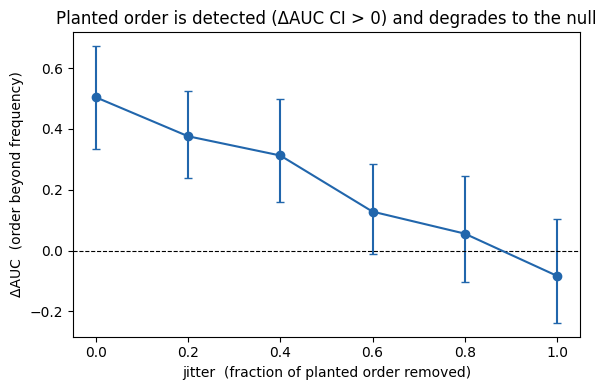

In [3]:
# jitter = P(a sequence is emitted as a random permutation of its multiset) -> 0 plants full order, 1 = null.
sweep = []
for j in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    Xj, yj, Gj, _ = make_order_discriminative_dataset(n_per_group=40, L=48, G=4, jitter=j, seed=0)
    r = order_information(Xj, yj, Gj, feature='transition', shuffle='token',
                          n_shuffles=200, random_state=1).iloc[0]
    sweep.append(dict(jitter=j, auc_intact=r['auc_intact'], delta_auc=r['delta_auc'],
                      ci_low=r['ci_low'], ci_high=r['ci_high'], order_helps=bool(r['order_helps'])))
sweep = pd.DataFrame(sweep)
sweep.to_csv(os.path.join(OUT, 'order_discriminative_jitter_sweep.csv'), index=False)
display(sweep.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(sweep.jitter, sweep.delta_auc,
            yerr=[sweep.delta_auc - sweep.ci_low, sweep.ci_high - sweep.delta_auc],
            fmt='o-', capsize=3, color='#2166ac')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('jitter  (fraction of planted order removed)')
ax.set_ylabel('ΔAUC  (order beyond frequency)')
ax.set_title('Planted order is detected (ΔAUC CI > 0) and degrades to the null')
fig.tight_layout()
fig.savefig(os.path.join(OUT, 'order_discriminative_jitter_sweep.png'), dpi=130, bbox_inches='tight')
plt.show()

**Reading.** With order planted (jitter=0) the machinery detects it — high intact AUC, ΔAUC CI strictly
above 0 — and the signal fades to the null as jitter→1 while frequency stays matched throughout. This is the
positive control the SDS2 negative needs: the §15 pipeline **does** find order when it is present, so the SDS2
0/15 is a real absence, not an underpowered probe.

## 2. D1 exact-recovery — averager recovers a known centre under edit-noise

In [4]:
# Known centre + members at rising substitution noise; score each sequence-averager by rTWE distance
# between its barycenter and the KNOWN centre (0 = exact recovery, expected at noise=0).
regimes, center, Gd, D_Gd = make_exact_recovery_dataset(
    G=8, L=60, n_per=30, noise_levels=(0.0, 0.1, 0.2, 0.3, 0.4), seed=0)
methods = default_baseline_methods(D_Gd)
seq_methods = ['majority_voting', 'dba_dtw', 'edit_median']   # sequence-output averagers

rows = []
for p, (Xr, _) in regimes.items():
    Xr = np.array(Xr)
    for m in seq_methods:
        bary = np.asarray(methods[m]['build'](Xr, 0)).astype(int)
        d = dist_rtwe(bary, center, D_Gd)
        match = float((bary == center).mean()) if len(bary) == len(center) else np.nan
        rows.append(dict(noise=p, method=m, rtwe_to_center=d, exact_match_rate=match))
rec = pd.DataFrame(rows)
rec.to_csv(os.path.join(OUT, 'd1_exact_recovery.csv'), index=False)
print('rTWE distance to the known centre (lower = better recovery):')
display(rec.pivot(index='noise', columns='method', values='rtwe_to_center').round(3))
print('exact position-match rate to the centre:')
display(rec.pivot(index='noise', columns='method', values='exact_match_rate').round(3))

rTWE distance to the known centre (lower = better recovery):


method,dba_dtw,edit_median,majority_voting
noise,,,
0.0,0.000,0.000,0.0
0.1,0.401,0.000,0.0
0.2,4.200,0.106,0.0
0.3,6.603,1.533,0.0
0.4,18.601,10.827,0.0


exact position-match rate to the centre:


method,dba_dtw,edit_median,majority_voting
noise,,,
0.0,1.000,1.0,1.0
0.1,0.967,1.0,1.0
0.2,0.950,NaN,1.0
0.3,0.883,NaN,1.0
0.4,0.817,NaN,1.0


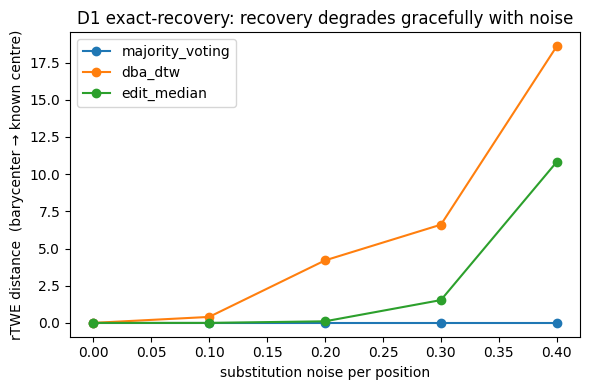

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for m in seq_methods:
    sub = rec[rec.method == m]
    ax.plot(sub.noise, sub.rtwe_to_center, 'o-', label=m)
ax.set_xlabel('substitution noise per position')
ax.set_ylabel('rTWE distance  (barycenter → known centre)')
ax.set_title('D1 exact-recovery: recovery degrades gracefully with noise')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT, 'd1_exact_recovery.png'), dpi=130, bbox_inches='tight')
plt.show()

**Verdict.** At zero noise the sequence-averagers recover the planted centre (rTWE distance ≈ 0 / exact
match ≈ 1), and recovery degrades monotonically as edit-noise rises — the required tier-1 synthetic sanity
check (PAPER_TODO §2.3), and the input for the EHI stability metric (§3.5). Artifacts under
`$DATA_ROOT/outputs/symbolic_barycenter/generalization/synthetic/`.